In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"D:\WeChat Files\wxid_vzlr2hkxrgil22\FileStorage\File\2024-10\insurance.csv")
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


1.画出因变量charges分布的直方图，以验证其分布是否为正态分布

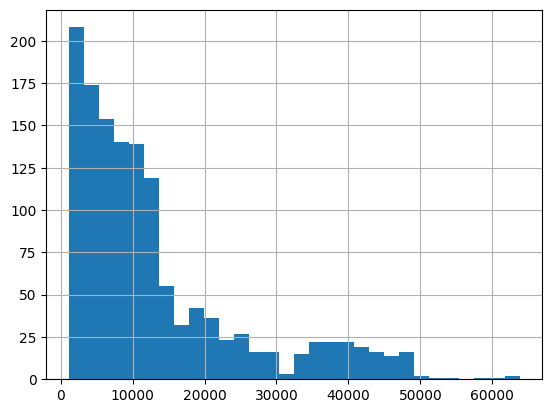

In [2]:
df['charges'].hist(bins=30)
plt.show()

显然这是一个右偏分布，不满足正态分布的性质

2.画出非数值类型特征“sex”、“smoker”以及“region”各自的频数分布图。画出“sex”与“smoker”间的散点气泡图。

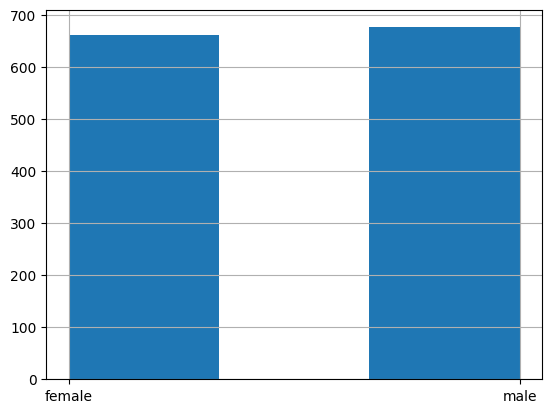

In [3]:
df['sex'].hist(bins=3)
plt.show()

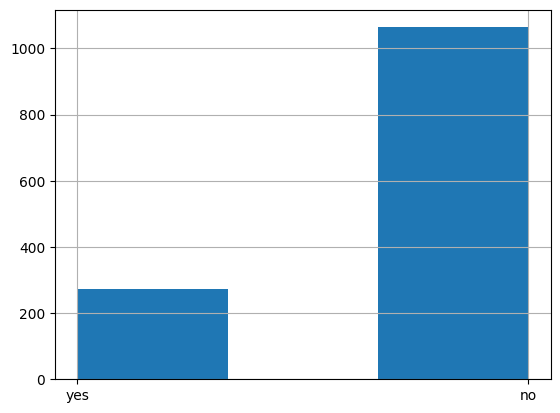

In [4]:
df['smoker'].hist(bins=3)
plt.show()

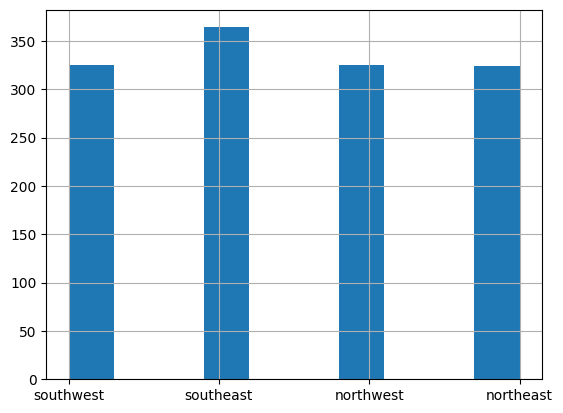

In [5]:
df['region'].hist()
plt.show()

In [6]:
df_new=df.groupby(['sex','smoker']).size().reset_index(name='count')
df_new

,sex,smoker,count
0,female,no,547
1,female,yes,115
2,male,no,517
3,male,yes,159


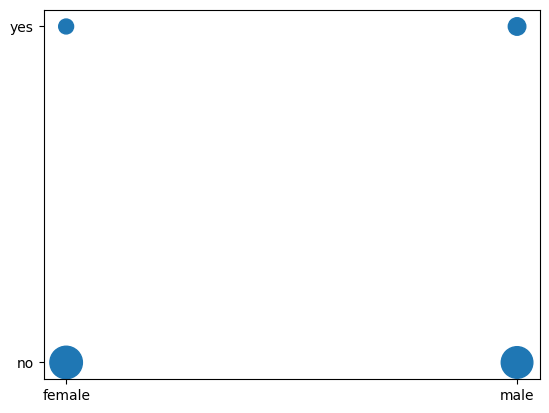

In [7]:
plt.scatter(x=df_new['sex'],y=df_new['smoker'],s=df_new['count'])
plt.show()

3.计算数值类型特征“age”、“bmi”、“children”以及“charges”之间的相关系数矩阵。

In [8]:
df[['age','bmi','children','charges']].corr()

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


4.对3个非数值类型特征进行顺序编码。

In [9]:
df=df.replace({'sex':{'female':0,'male':1}})
df=df.replace({'smoker':{'no':0,'yes':1}})
df=df.replace({'region':{'southwest':0,'northwest':1,'southeast':2,'northeast':3}})

C:\Users\27968\AppData\Local\Temp\ipykernel_55524\3029561848.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df=df.replace({'sex':{'female':0,'male':1}})
C:\Users\27968\AppData\Local\Temp\ipykernel_55524\3029561848.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df=df.replace({'smoker':{'no':0,'yes':1}})
C:\Users\27968\AppData\Local\Temp\ipykernel_55524\3029561848.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result

In [10]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,0,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1,10600.54830
1334,18,0,31.920,0,0,3,2205.98080
1335,18,0,36.850,0,0,2,1629.83350
1336,21,0,25.800,0,0,0,2007.94500


5.建立线性回归模型，随机选取20%的数据作为测试集，80%的数据作为训练集，在测试集上计算性能评价指标（均方误差MSE以及决定系数R2）。要求分别用梯度下降法（自己编写函数，不能调用sklearn中的函数）和调用sklearn中封装好的函数来实现。

1. 损失函数

In [11]:
#变量均为向量，向量化
def cost_function(x,y,theta):
    m=x.shape[0]
    h=np.dot(x,theta)-y
    cost= np.dot(h.T,h)/(2*m)
    return cost

2. 计算梯度

In [12]:
def grad(x, y,theta):
    m = x.shape[0]
    h=np.dot(x,theta)
    return np.dot(x.T,(h-y))/m

In [13]:
X = df[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
y = df['charges']

In [14]:
X.shape

(1338, 6)

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

3. 梯度下降算法

In [16]:
def gardient_descent(theta, x, y,alpha,N):
    cost_data=[cost_function(x,y,theta)]
    theta_new=theta
    for i in range(N):
        theta_new=theta_new-alpha*grad(x,y,theta_new)
        cost_data.append(cost_function(x,y,theta_new))
    return theta_new,cost_data

In [17]:
theta1=[0,0,0,0,0,0]
theta1=np.array(theta1)
alpha=0.0005
N=100000
#这里出现了很大的问题，一开始学习率取了0.05，结果一直nan，cost函数显示递增，
# 一开始以为是函数写错了，多方修改无果，后大量搜索调试才发现学习率取太大了，容易越过最低点曲折离开，从而造成发散
# 因此学习率的高低有经验可循，但更重要的是尝试

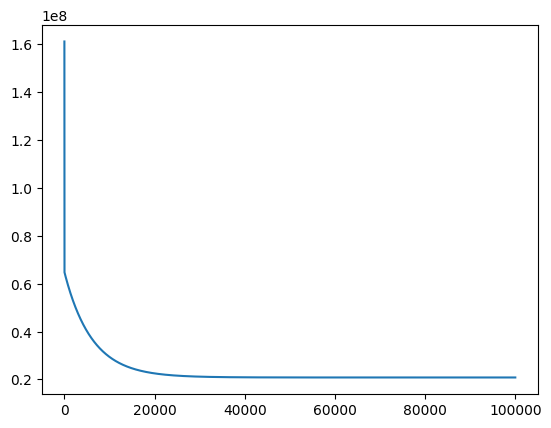

In [18]:
theta,cost_data= gardient_descent(theta1,X_train, y_train,alpha,N)
plt.plot(cost_data)

In [19]:
y_pred = np.dot(X_test, theta)

In [20]:
# 计算MSE和R2
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"梯度下降法 - MSE: {mse}")
print(f"梯度下降法 - R2: {r2}")

梯度下降法 - MSE: 38545118.64263568
梯度下降法 - R2: 0.7517202345406722


4. sklearn

In [21]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(X_train,y_train)

LinearRegression()

In [22]:
y_pred_sk=reg.predict(X_test)

In [23]:
sk_mse = mean_squared_error(y_test, y_pred_sk)
sk_r2 = r2_score(y_test, y_pred_sk)

In [24]:
print(f"sklearn - MSE: {sk_mse}")
print(f"sklearn - R2: {sk_r2}")

sklearn - MSE: 33927609.01712134
sklearn - R2: 0.7814628906071344


6.添加非线性关系：（1）创建新变量age2，其值为age的平方；（2）将bmi变量转化为一个二进制变量bmi30（即大于等于30为1，否则为0）；（3）加入相互作用的影响，例如创建新变量bmi30_smoker，其值为两者的乘积。把上述3个新变量加入线性回归模型，类似步骤5通过验证评价指标（MSE以及R2），来比较模型性能是否提高。此步骤调用sklearn中封装好的函数来实现。

In [25]:
df['age2']=df['age']**2
df['bmi30'] = (df['bmi'] >= 30).astype(int) ##转化为哑变量
df['bmi30_smoker'] = df['bmi30'] * df['smoker']

In [32]:
df

,age,sex,bmi,children,smoker,region,charges,age2,bmi30,bmi30_smoker
0,19,0,27.900,0,1,0,16884.92400,361,0,0
1,18,1,33.770,1,0,2,1725.55230,324,1,0
2,28,1,33.000,3,0,2,4449.46200,784,1,0
3,33,1,22.705,0,0,1,21984.47061,1089,0,0
4,32,1,28.880,0,0,1,3866.85520,1024,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1,10600.54830,2500,1,0
1334,18,0,31.920,0,0,3,2205.98080,324,1,0
1335,18,0,36.850,0,0,2,1629.83350,324,1,0
1336,21,0,25.800,0,0,0,2007.94500,441,0,0


In [26]:
X_new = df[['age', 'sex', 'bmi', 'children', 'smoker', 'region','age2','bmi30','bmi30_smoker']]

In [27]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y, test_size=0.2, random_state=42)

In [28]:
reg_new=LinearRegression()
reg_new.fit(X_train_new,y_train_new)

LinearRegression()

In [29]:
y_pred_new=reg_new.predict(X_test_new)

In [30]:
new_mse = mean_squared_error(y_test_new, y_pred_new)
new_r2 = r2_score(y_test_new, y_pred_new)

In [31]:
print(f"sklearn - MSE: {new_mse}")
print(f"sklearn - R2: {new_r2}")

sklearn - MSE: 19196707.703209247
sklearn - R2: 0.8763486985127059
